# K-means 聚类：用多种指标选择簇数

本实验使用 `scikit-learn` 完成 K-means 聚类。主要观察两个问题：

1. 不同评价指标如何帮助选择簇数 $K$；
2. 聚类结果如何随 $K$ 的增加而变化。

In [1]:
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib
configure_matplotlib()
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    fowlkes_mallows_score,
    rand_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
SINGLE_FIGSIZE = (8, 5.5)

## 1. 生成并标准化数据

生成三个近似球形的二维簇。变量 `y_true` 只用于演示外部评价指标，不参与 K-means 拟合。

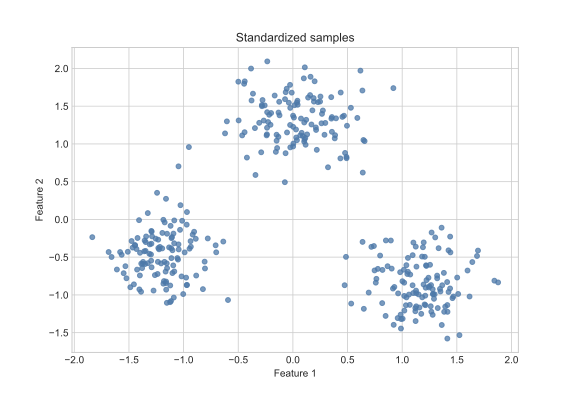

In [2]:
X, y_true = make_blobs(
    n_samples=360,
    centers=[(-4, -1), (0, 4), (4, -2)],
    cluster_std=[0.85, 1.00, 0.90],
    random_state=42,
)
X_scaled = StandardScaler().fit_transform(X)

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE)
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], s=24, alpha=0.75, color="#4C78A8")
ax.set(title="Standardized samples", xlabel="Feature 1", ylabel="Feature 2")
plt.show()

## 2. 计算全部评价指标

对 $K=1,2,\dots,8$ 分别拟合 K-means。WCSS 使用肘部位置判断；CH、Silhouette、RI、ARI 和 FMI 均取较大值。

CH 与 Silhouette 是内部指标，只依赖样本和聚类标签。RI、ARI 与 FMI 是外部指标，需要已知真实标签，因此在实际无监督任务中通常不能用于选择 $K$。

In [3]:
all_k = range(1, 9)
candidate_k = range(2, 9)
models = {}
rows = []

for k in all_k:
    model = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)
    models[k] = model

    if k >= 2:
        rows.append(
            {
                "K": k,
                "WCSS": model.inertia_,
                "CH": calinski_harabasz_score(X_scaled, labels),
                "Silhouette": silhouette_score(X_scaled, labels),
                "RI": rand_score(y_true, labels),
                "ARI": adjusted_rand_score(y_true, labels),
                "FMI": fowlkes_mallows_score(y_true, labels),
            }
        )

metrics = pd.DataFrame(rows).set_index("K")
metrics.round(3)

,WCSS,CH,Silhouette,RI,ARI,FMI
K,,,,,,
2,346.953,384.926,0.551,0.777,0.570,0.773
3,64.141,1825.206,0.755,1.000,1.000,1.000
4,55.314,1426.270,0.622,0.947,0.874,0.916
5,46.982,1271.359,0.481,0.889,0.728,0.816
6,39.308,1226.049,0.364,0.838,0.582,0.714
7,33.877,1191.580,0.368,0.818,0.525,0.672
8,30.578,1133.772,0.345,0.796,0.456,0.620


## 3. 比较指标曲线

WCSS 在 $K=3$ 附近由陡降转为平缓。其余指标的黑点表示各自的最大值。

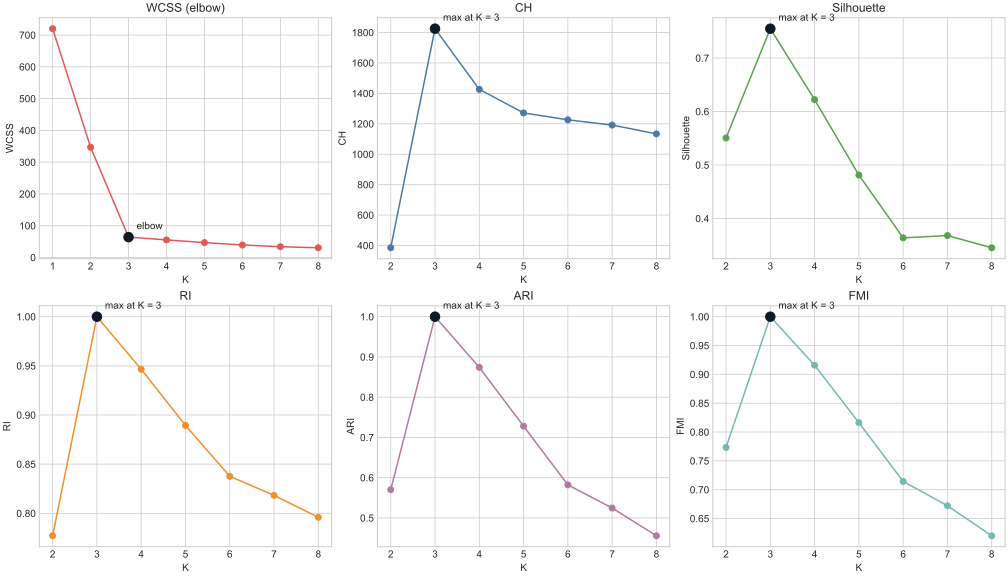

In [4]:
chosen_k = 3
wcss = [models[k].inertia_ for k in all_k]
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(list(all_k), wcss, marker="o", color="#E45756")
axes[0, 0].scatter(chosen_k, wcss[chosen_k - 1], s=90, color="#111827", zorder=3)
axes[0, 0].annotate("elbow", (chosen_k, wcss[chosen_k - 1]), xytext=(8, 8), textcoords="offset points")
axes[0, 0].set(title="WCSS (elbow)", xlabel="K", ylabel="WCSS", xticks=list(all_k))

for ax, metric, color in zip(
    axes.flat[1:],
    ["CH", "Silhouette", "RI", "ARI", "FMI"],
    ["#4C78A8", "#59A14F", "#F28E2B", "#B279A2", "#76B7B2"],
):
    values = metrics[metric]
    best_k = int(values.idxmax())
    ax.plot(values.index, values, marker="o", color=color)
    ax.scatter(best_k, values.loc[best_k], s=90, color="#111827", zorder=3)
    ax.annotate(f"max at K = {best_k}", (best_k, values.loc[best_k]), xytext=(8, 8), textcoords="offset points")
    ax.set(title=metric, xlabel="K", ylabel=metric, xticks=list(candidate_k))

plt.show()

## 4. 查看每一个 $K$ 的聚类结果

下图依次展示 $K=1,2,\dots,8$ 的划分。星号表示簇中心。随着 $K$ 增大，原有样本群会被进一步拆分。

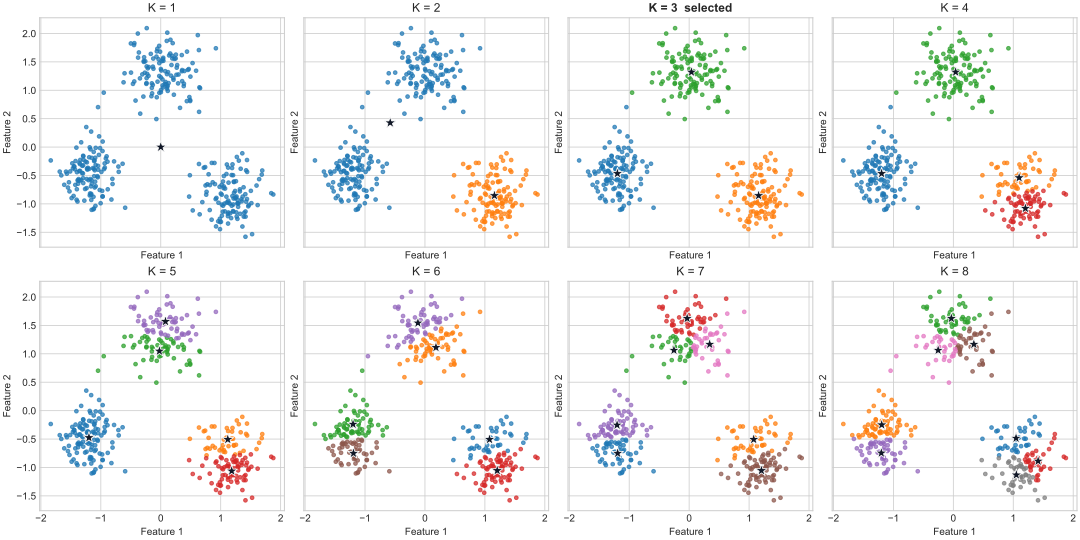

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), sharex=True, sharey=True, constrained_layout=True)
colors = plt.get_cmap("tab10")

for ax, k in zip(axes.flat, all_k):
    model = models[k]
    labels = model.labels_
    for label in range(k):
        points = X_scaled[labels == label]
        ax.scatter(points[:, 0], points[:, 1], s=14, alpha=0.72, color=colors(label))
    ax.scatter(
        model.cluster_centers_[:, 0],
        model.cluster_centers_[:, 1],
        marker="*",
        s=150,
        color="#111827",
        edgecolor="white",
        linewidth=0.8,
    )
    title = f"K = {k}" + ("  selected" if k == chosen_k else "")
    ax.set_title(title, fontweight="bold" if k == chosen_k else "normal")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.show()

## 观察

本例中，各项指标都支持 $K=3$。当 $K<3$ 时，彼此分离的样本群被合并；当 $K>3$ 时，已有样本群被人为拆分。实际数据没有真实标签时，应主要结合 WCSS、CH、Silhouette 和聚类图作出判断。